<a href="https://colab.research.google.com/github/RidhoAnfaal/PCVK_Ganjil_2025/blob/main/Week7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from skimage import io
import os
import glob
from google.colab.patches import cv2_imshow
from PIL import Image as im

# 1. Tampilkan histogram tiap citra dan analisis distribusi intensitasnya.

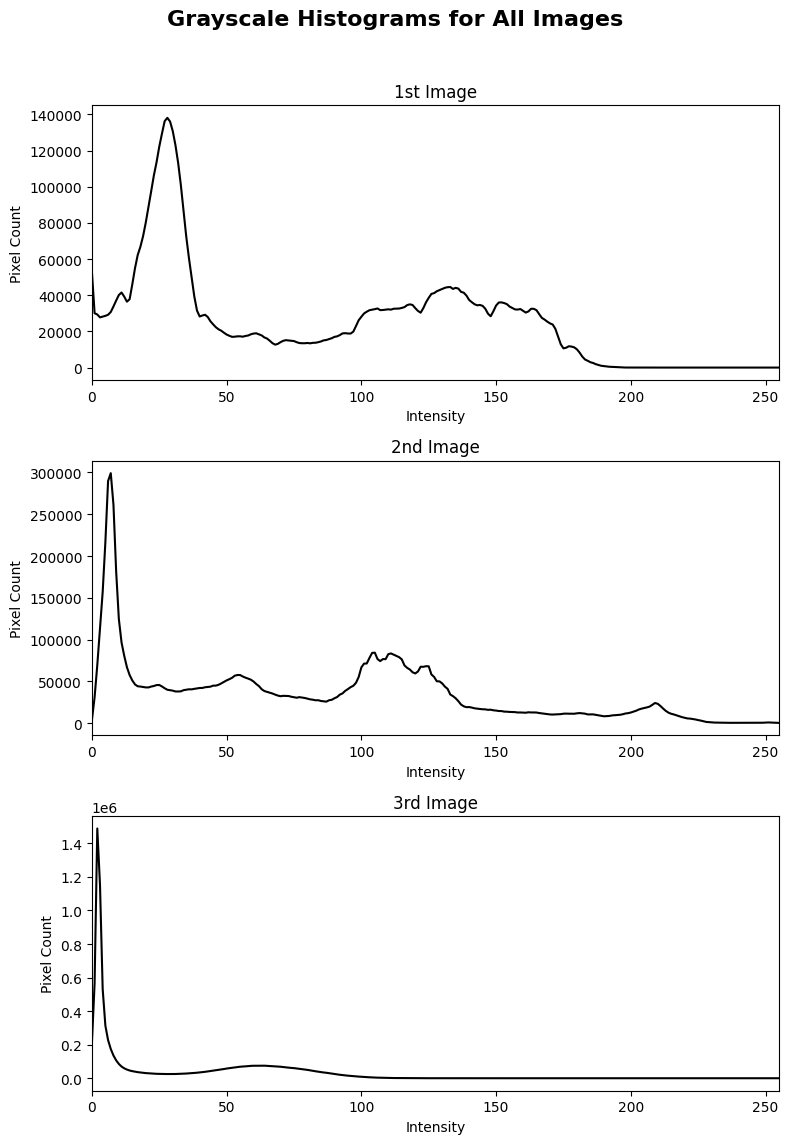

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img1 = cv.imread('/content/drive/MyDrive/PCVK/img1fnormal.jpg', cv.IMREAD_GRAYSCALE)
img2 = cv.imread('/content/drive/MyDrive/PCVK/img2fhalfbrighthalfdark.jpg', cv.IMREAD_GRAYSCALE)
img3 = cv.imread('/content/drive/MyDrive/PCVK/img3fdark.jpg', cv.IMREAD_GRAYSCALE)

images = [img1, img2, img3]
titles = ['1st Image', '2nd Image', '3rd Image']

fig, axs = plt.subplots(3, 1, figsize=(8, 12))
fig.suptitle('Grayscale Histograms for All Images', fontsize=16, fontweight='bold')

for i, img in enumerate(images):
    hist = cv.calcHist([img], [0], None, [256], [0, 256])

    axs[i].plot(hist, color='black')
    axs[i].set_title(titles[i])
    axs[i].set_xlabel('Intensity')
    axs[i].set_ylabel('Pixel Count')
    axs[i].set_xlim([0, 255])

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

# 2. Terapkan transformasi brightness dan contrast (linear/log brightness). Tentukan nilai b (brightness) dan a (contrast) yang sesuai agar wajah tampak natural.

Enter value of alpha: 5
Enter value of beta: 100


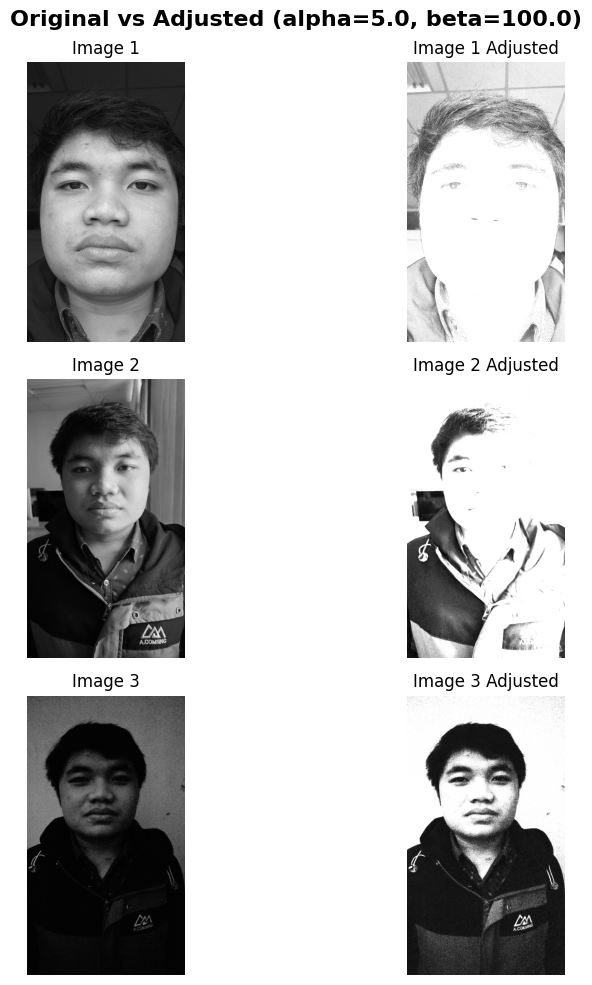

In [ ]:
listImg = [img1, img2, img3]

try:
    alpha = float(input("Enter value of alpha: "))
    beta = float(input("Enter value of beta: "))
except ValueError:
    print("Error, not a number")

adjusted_Imglist = []
for img in listImg:
    adjusted = cv.convertScaleAbs(img, alpha=alpha, beta=beta)
    adjusted_Imglist.append(adjusted)


titles = ['Image 1', 'Image 2', 'Image 3']
title_adj = ['Image 1 Adjusted', 'Image 2 Adjusted', 'Image 3 Adjusted']

fig, axs = plt.subplots(len(listImg), 2, figsize=(10, 10))
fig.suptitle(f'Original vs Adjusted (alpha={alpha}, beta={beta})', fontsize=16, fontweight='bold')

for i in range(len(listImg)):
    axs[i, 0].imshow(listImg[i], cmap='gray')
    axs[i, 0].set_title(titles[i])
    axs[i, 0].axis('off')

    axs[i, 1].imshow(adjusted_Imglist[i], cmap='gray')
    axs[i, 1].set_title(title_adj[i])
    axs[i, 1].axis('off')

plt.tight_layout()
plt.show()

# 3. Lakukan histogram equalization untuk memperbaiki sebaran kontras. Bandingkan hasil visual dan histogram sebelum–sesudah.

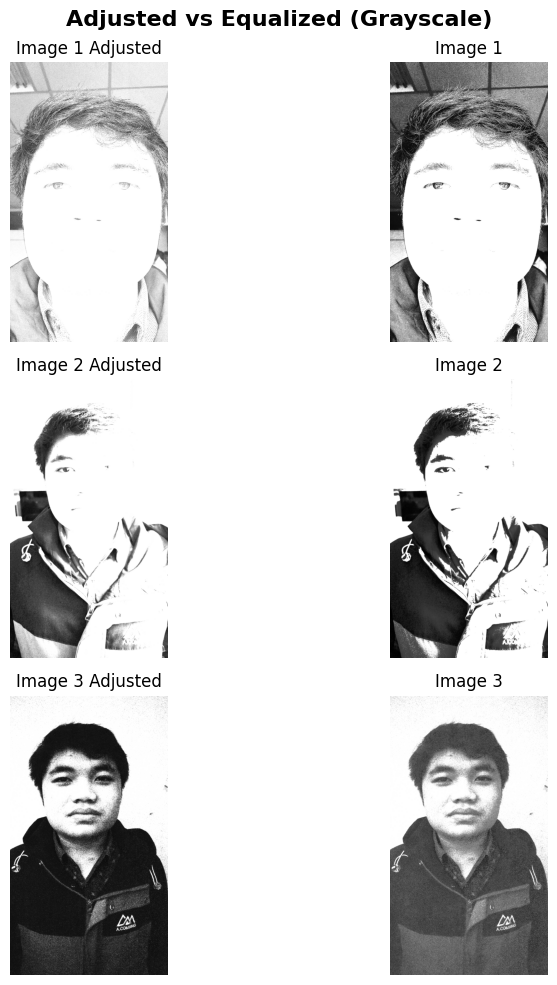

In [ ]:
equalized_Imglist = []
for img in adjusted_Imglist:
    equalizedImg = cv.equalizeHist(img)
    equalized_Imglist.append(equalizedImg)


fig, axs = plt.subplots(len(equalized_Imglist), 2, figsize=(10, 10))
fig.suptitle('Adjusted vs Equalized (Grayscale)', fontsize=16, fontweight='bold')

for i in range(len(equalized_Imglist)):
    axs[i, 0].imshow(adjusted_Imglist[i], cmap='gray')
    axs[i, 0].set_title(title_adj[i])
    axs[i, 0].axis('off')

    axs[i, 1].imshow(equalized_Imglist[i], cmap='gray')
    axs[i, 1].set_title(titles[i])
    axs[i, 1].axis('off')

plt.tight_layout()
plt.show()

# 4. Terapkan filter spasial:
# o Low-pass filter untuk menghaluskan noise kulit wajah.
# o High-pass atau Laplacian filter untuk menajamkan tepi mata dan bibir.

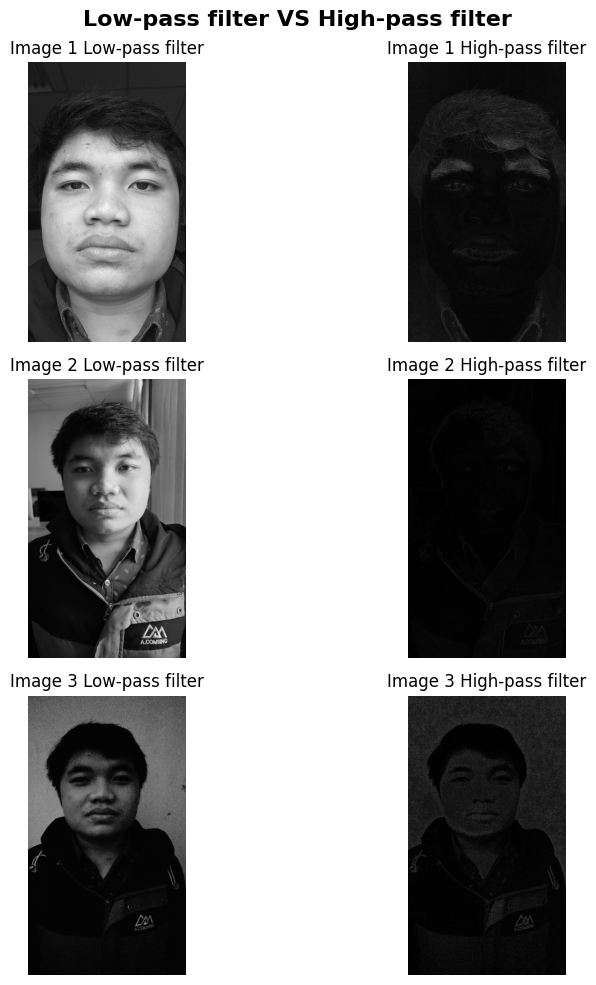

In [ ]:
kernel = np.ones((3, 3), np.float32) / 9

smoothed_Imglist = []
for img in listImg:
    smoothedImg = cv.filter2D(img, -1, kernel)
    smoothed_Imglist.append(smoothedImg)


kernelHP = np.array([[-1, -1, -1],
                     [-1, 8, -1],
                     [-1, -1, -1]])


sharpened_Imglist = []
for i in range(len(listImg)):
    sharpenedImg = cv.filter2D(listImg[i], -1, kernelHP)
    sharpened_Imglist.append(sharpenedImg)


fig, axs = plt.subplots(len(equalized_Imglist), 2, figsize=(10, 10))
fig.suptitle('Low-pass filter VS High-pass filter', fontsize=16, fontweight='bold')
for i in range(len(listImg)):
  axs[i, 0].imshow(smoothed_Imglist[i], cmap='gray')
  axs[i, 0].set_title('Image ' + str(i+1) + ' Low-pass filter')
  axs[i, 0].axis('off')

  axs[i, 1].imshow(sharpened_Imglist[i], cmap='gray')
  axs[i, 1].set_title('Image ' + str(i+1) + ' High-pass filter')
  axs[i, 1].axis('off')

plt.tight_layout()
plt.show()

# 5. Implementasikan Floyd–Steinberg Dithering untuk menurunkan kedalaman warna wajah (bit-depth 4–6 bit), lalu analisis bagaimana efeknya terhadap detail danekspresi wajah.

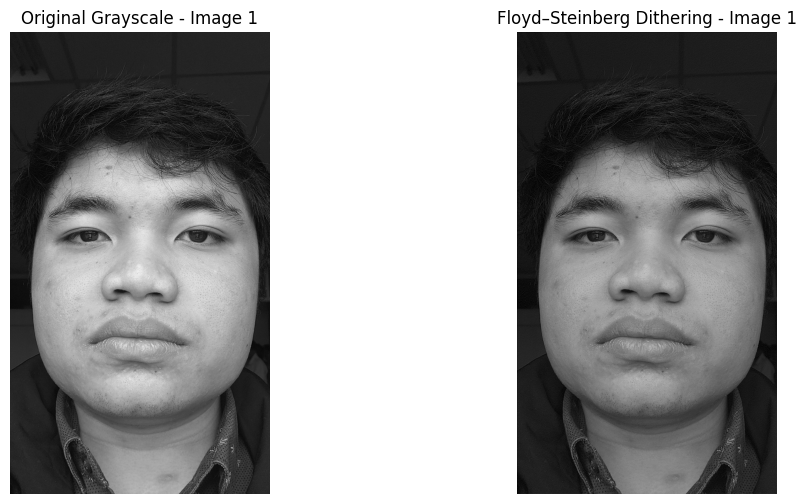

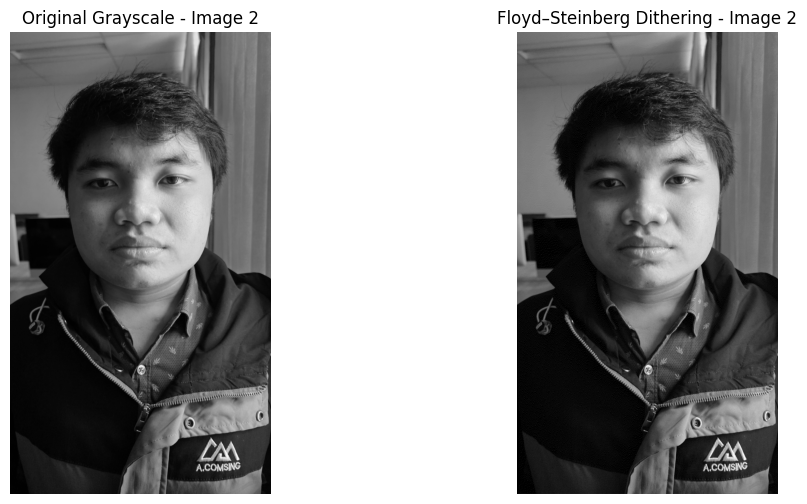

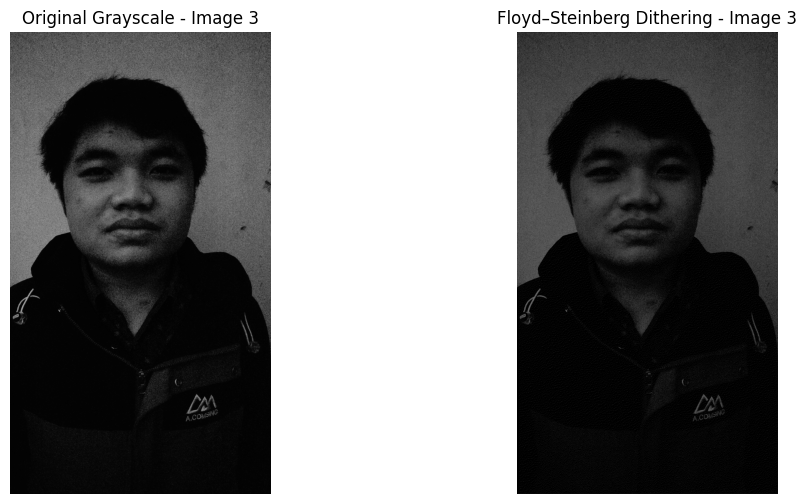

In [ ]:
image_paths = [
    '/content/drive/MyDrive/PCVK/img1fnormal.jpg',
    '/content/drive/MyDrive/PCVK/img2fhalfbrighthalfdark.jpg',
    '/content/drive/MyDrive/PCVK/img3fdark.jpg'
]

for i, path in enumerate(image_paths, start=1):
    img_gray = cv.imread(path, cv.IMREAD_GRAYSCALE)

    dither_img = img_gray.astype(np.float32)
    height, width = dither_img.shape

    for y in range(height - 1):
        for x in range(1, width - 1):
            old_pixel = dither_img[y, x]
            new_pixel = 0 if old_pixel < 128 else 255
            dither_img[y, x] = new_pixel
            error = old_pixel - new_pixel

            dither_img[y,   x+1] += error * 7/16
            dither_img[y+1, x-1] += error * 3/16
            dither_img[y+1, x  ] += error * 5/16
            dither_img[y+1, x+1] += error * 1/16

    dither_img = np.clip(dither_img, 0, 255).astype(np.uint8)

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.title(f"Original Grayscale - Image {i}")
    plt.imshow(img_gray, cmap='gray')
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.title(f"Floyd–Steinberg Dithering - Image {i}")
    plt.imshow(dither_img, cmap='gray')
    plt.axis("off")

    plt.show()

Processing 6-bit: 100%|██████████| 3391/3391 [00:46<00:00, 72.72it/s]


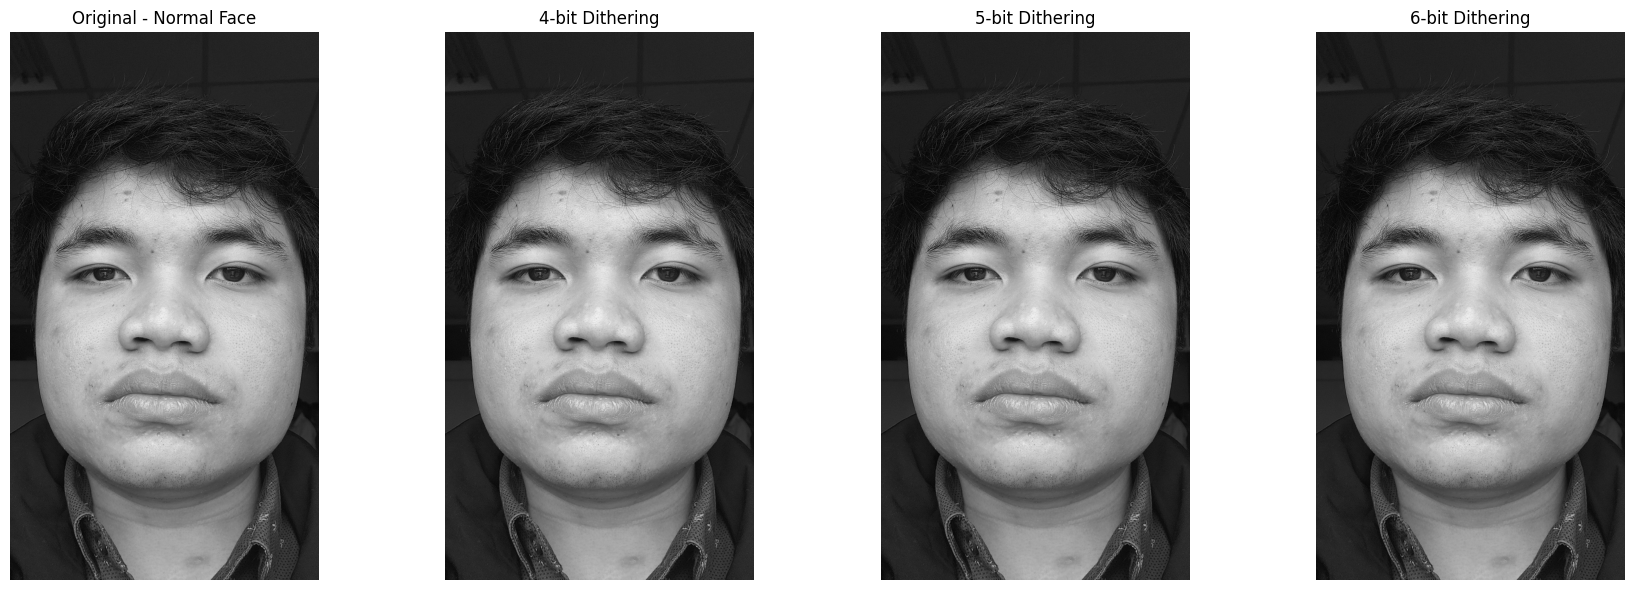

Processing 6-bit: 100%|██████████| 3999/3999 [01:08<00:00, 57.96it/s]


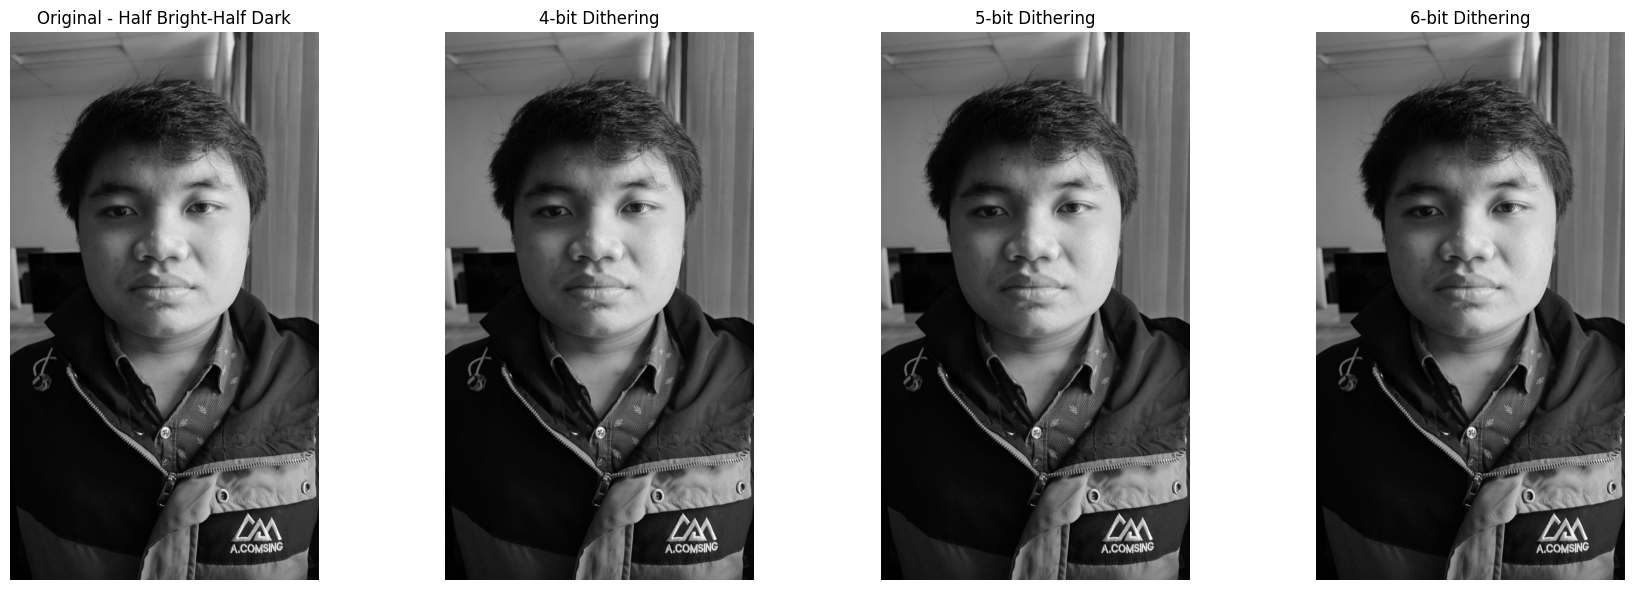

Processing 6-bit: 100%|██████████| 3999/3999 [01:13<00:00, 54.43it/s]


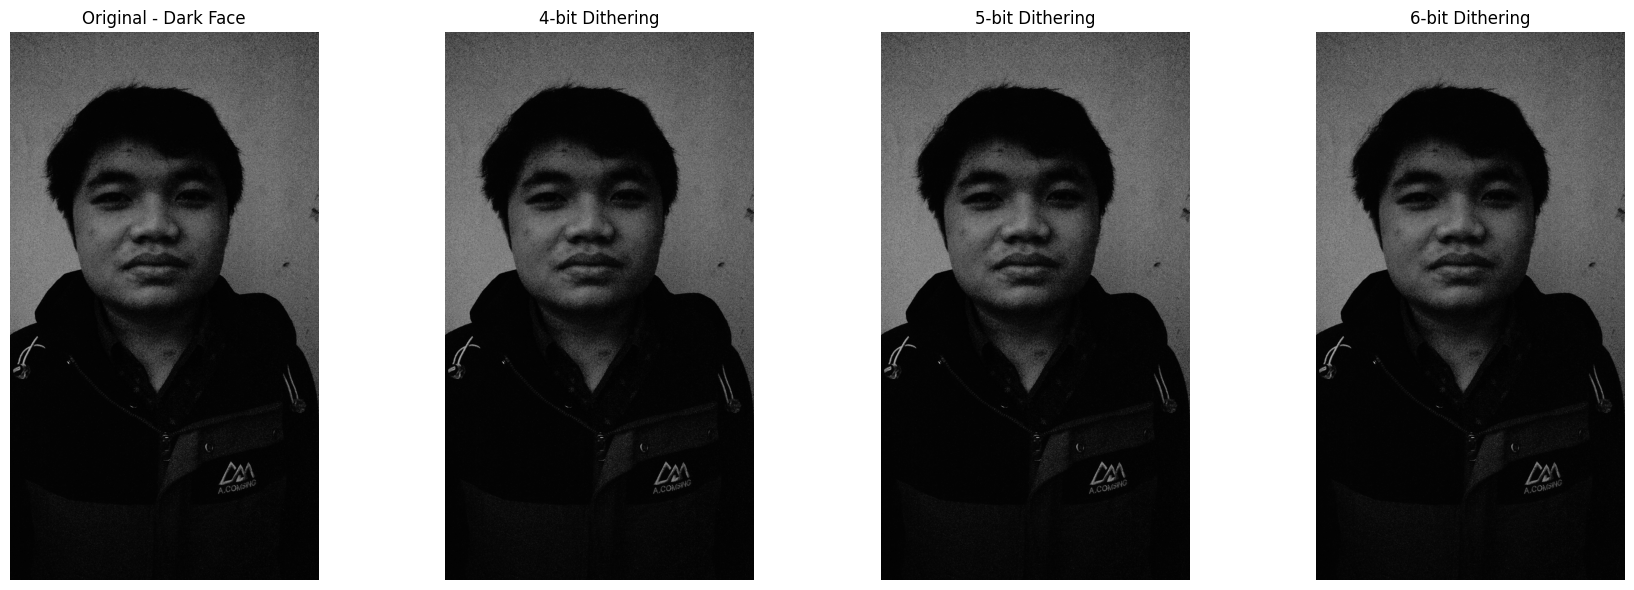

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm  # Optional for progress bar

# --- Assume you already have grayscale images ---
# Example:
# img1 = cv.imread('/content/drive/MyDrive/PCVK/img1fnormal.jpg', cv.IMREAD_GRAYSCALE)
# img2 = cv.imread('/content/drive/MyDrive/PCVK/img2fhalfbrighthalfdark.jpg', cv.IMREAD_GRAYSCALE)
# img3 = cv.imread('/content/drive/MyDrive/PCVK/img3fdark.jpg', cv.IMREAD_GRAYSCALE)

images = [img1, img2, img3]
titles = ['Normal Face', 'Half Bright-Half Dark', 'Dark Face']

# --- Bit depths to simulate ---
bit_depths = [4, 5, 6]

# --- Floyd–Steinberg Dithering Function ---
def floyd_steinberg_dither(image, bit_depth):
    levels = 2 ** bit_depth
    step = 255 / (levels - 1)
    dither = image.astype(np.float32)
    h, w = dither.shape

    for y in tqdm(range(h - 1), desc=f"Processing {bit_depth}-bit"):
        for x in range(1, w - 1):
            old_pixel = dither[y, x]
            new_pixel = np.round(old_pixel / step) * step
            dither[y, x] = new_pixel
            error = old_pixel - new_pixel

            # Floyd–Steinberg diffusion
            dither[y,   x+1] += error * 7/16
            dither[y+1, x-1] += error * 3/16
            dither[y+1, x  ] += error * 5/16
            dither[y+1, x+1] += error * 1/16

    return np.clip(dither, 0, 255).astype(np.uint8)

# --- Loop through each image and apply dithering ---
for i, img_gray in enumerate(images):
    plt.figure(figsize=(18, 6))
    plt.subplot(1, len(bit_depths) + 1, 1)
    plt.title(f"Original - {titles[i]}")
    plt.imshow(img_gray, cmap='gray')
    plt.axis("off")

    for j, bd in enumerate(bit_depths, start=2):
        dither_img = floyd_steinberg_dither(img_gray, bd)
        plt.subplot(1, len(bit_depths) + 1, j)
        plt.title(f"{bd}-bit Dithering")
        plt.imshow(dither_img, cmap='gray')
        plt.axis("off")

    plt.tight_layout()
    plt.show()

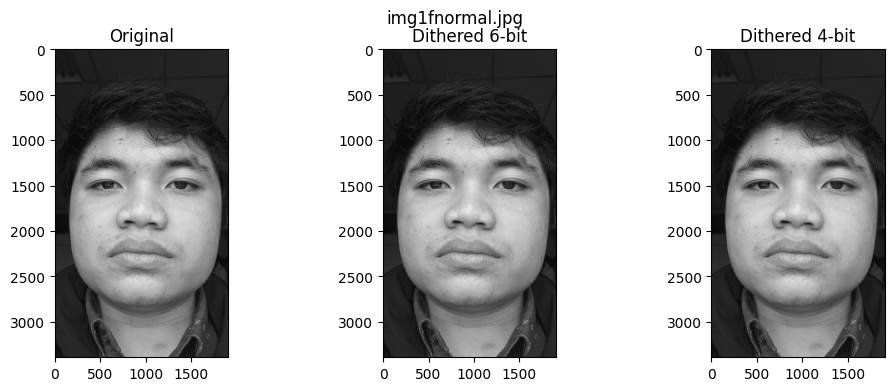

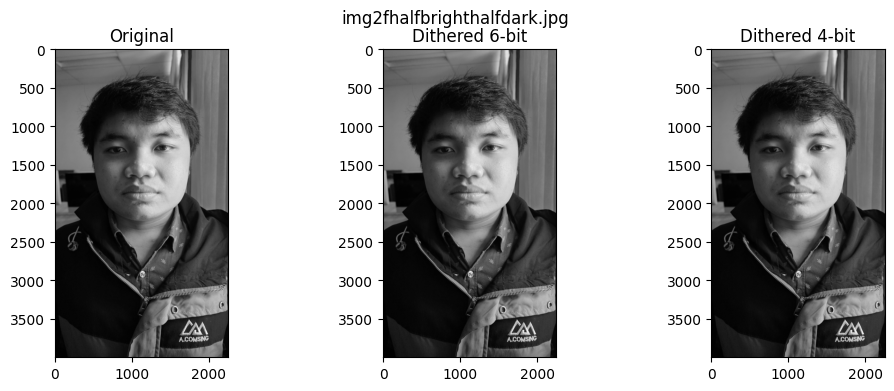

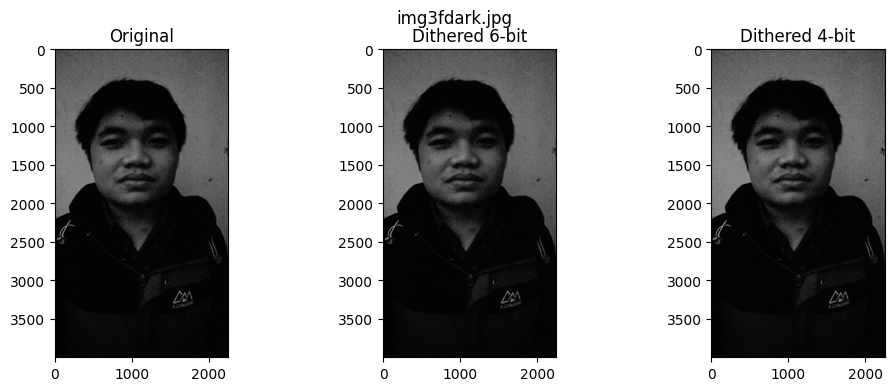

In [ ]:
import cv2

def floyd_steinberg_dither(img, bit_depth):
    gray = img.astype(np.float32)

    levels = 2 ** bit_depth
    step = 256 // levels

    h, w = gray.shape
    for y in range(h - 1):
        for x in range(1, w - 1):
            old_pixel = gray[y, x]
            new_pixel = np.round(old_pixel / step) * step
            gray[y, x] = new_pixel
            error = old_pixel - new_pixel

            gray[y,   x+1] += error * 7/16
            gray[y+1, x-1] += error * 3/16
            gray[y+1, x]   += error * 5/16
            gray[y+1, x+1] += error * 1/16

    return np.clip(gray, 0, 255).astype(np.uint8)

paths = [
    '/content/drive/MyDrive/PCVK/img1fnormal.jpg',
    '/content/drive/MyDrive/PCVK/img2fhalfbrighthalfdark.jpg',
    '/content/drive/MyDrive/PCVK/img3fdark.jpg'
]

for path in paths:
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    dithered_6bit = floyd_steinberg_dither(img, 6)
    dithered_4bit = floyd_steinberg_dither(img, 4)

    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1); plt.imshow(img, cmap='gray'); plt.title('Original')
    plt.subplot(1,3,2); plt.imshow(dithered_6bit, cmap='gray'); plt.title('Dithered 6-bit')
    plt.subplot(1,3,3); plt.imshow(dithered_4bit, cmap='gray'); plt.title('Dithered 4-bit')
    plt.suptitle(path.split('/')[-1])
    plt.show()

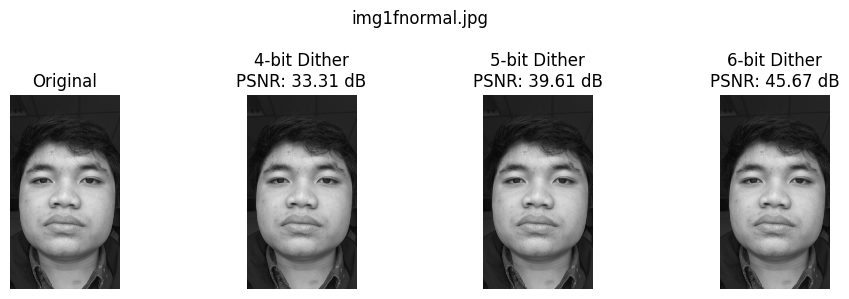

Image: img1fnormal.jpg
PSNR (4-bit): 33.31 dB
PSNR (5-bit): 39.61 dB
PSNR (6-bit): 45.67 dB



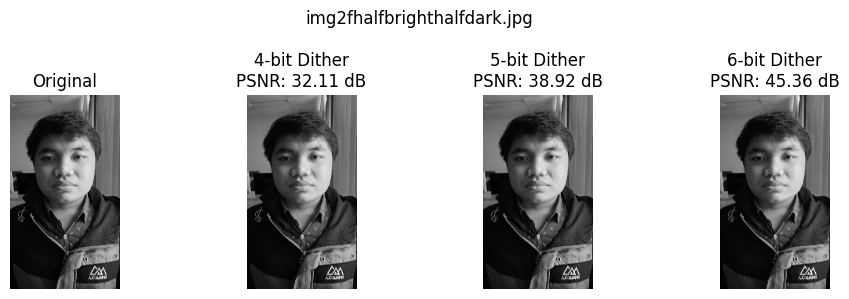

Image: img2fhalfbrighthalfdark.jpg
PSNR (4-bit): 32.11 dB
PSNR (5-bit): 38.92 dB
PSNR (6-bit): 45.36 dB



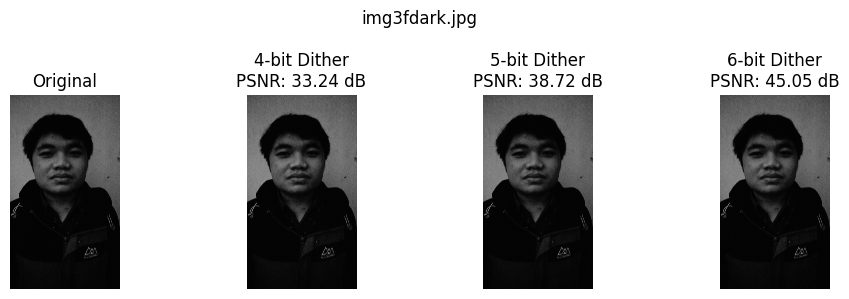

Image: img3fdark.jpg
PSNR (4-bit): 33.24 dB
PSNR (5-bit): 38.72 dB
PSNR (6-bit): 45.05 dB



In [ ]:
import math

photos = [
    '/content/drive/MyDrive/PCVK/img1fnormal.jpg',
    '/content/drive/MyDrive/PCVK/img2fhalfbrighthalfdark.jpg',
    '/content/drive/MyDrive/PCVK/img3fdark.jpg'
]

def floyd_steinberg(img, bit_depth):
    gray = img.astype(np.float32)
    levels = 2 ** bit_depth
    step = 256 // levels
    h, w = gray.shape

    for y in range(h - 1):
        for x in range(1, w - 1):
            old_pixel = gray[y, x]
            new_pixel = np.round(old_pixel / step) * step
            gray[y, x] = new_pixel
            error = old_pixel - new_pixel

            gray[y,   x+1] += error * 7/16
            gray[y+1, x-1] += error * 3/16
            gray[y+1, x  ] += error * 5/16
            gray[y+1, x+1] += error * 1/16

    return np.clip(gray, 0, 255).astype(np.uint8)

def calculate_psnr(original, processed):
    mse = np.mean((original.astype(np.float32) - processed.astype(np.float32)) ** 2)
    psnr = 10 * math.log10((255 ** 2) / mse)
    return psnr

for path in photos:
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    dithered_6bit = floyd_steinberg(img, 6)
    dithered_5bit = floyd_steinberg(img, 5)
    dithered_4bit = floyd_steinberg(img, 4)

    psnr_6bit = calculate_psnr(img, dithered_6bit)
    psnr_5bit = calculate_psnr(img, dithered_5bit)
    psnr_4bit = calculate_psnr(img, dithered_4bit)

    plt.figure(figsize=(10, 3))
    plt.subplot(1, 4, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Original')
    plt.axis('off')

    plt.subplot(1, 4, 2)
    plt.imshow(dithered_4bit, cmap='gray')
    plt.title(f'4-bit Dither\nPSNR: {psnr_4bit:.2f} dB')
    plt.axis('off')


    plt.subplot(1, 4, 3)
    plt.imshow(dithered_5bit, cmap='gray')
    plt.title(f'5-bit Dither\nPSNR: {psnr_5bit:.2f} dB')
    plt.axis('off')

    plt.subplot(1, 4, 4)
    plt.imshow(dithered_6bit, cmap='gray')
    plt.title(f'6-bit Dither\nPSNR: {psnr_6bit:.2f} dB')
    plt.axis('off')

    plt.suptitle(path.split('/')[-1])
    plt.tight_layout()
    plt.show()

    print(f"Image: {path.split('/')[-1]}")
    print(f"PSNR (4-bit): {psnr_4bit:.2f} dB")
    print(f"PSNR (5-bit): {psnr_5bit:.2f} dB")
    print(f"PSNR (6-bit): {psnr_6bit:.2f} dB\n")